# F2 - Protein-derangement null: does the model USE the protein?
**Question.** Given the honest de-peek (S1_depeek) is not distinguishable from an RNA-only baseline (S3), is the model even *conditioning* on the protein, or is it pure RNA memorization? Counterfactual: feed the WRONG protein for each held pair and see if the prediction survives.

*Data: `mmpartnet_out/famfull3_derangement_null.json` (folds 0/2/4 -- the surviving saved adapters; 1,3 tensors were deleted under the disk quota). Inference-only on a CUDA GPU.*

## Definitions / math
- **Derangement** $\sigma$: a fixed-point-free permutation of the protein assignment across held pairs (no pair keeps its true protein), RNA window + ORIGINAL label unchanged. 3 seeds/fold.
- **deranged MCC** = MCC(model prediction on $(RNA, \sigma(\text{protein}))$, ORIGINAL label).
- **drop** = honest - deranged.
- **Read:** drop $\approx 0$ (deranged $\approx$ honest) -> protein IGNORED (pure RNA memorization); drop large / deranged -> chance -> the prediction DEPENDS on the protein input. NB this tests protein USE, not protein-family TRANSFER (a model that memorized seen (protein,RNA) pairs also collapses here).

In [1]:
import json; from pathlib import Path; from IPython.display import Markdown, display
d = json.loads((Path('..')/'..'/'mmpartnet_out'/'famfull3_derangement_null.json').read_text())
t = '| fold | honest MCC | deranged-protein MCC (3 seeds) | drop |\n|---|---|---|---|\n'
hs=[]; ds=[]
for k in sorted(d, key=int):
    v=d[k]; hs.append(v['honest']); ds.append(v['deranged_mean'])
    t += f"| {k} | {v['honest']:.3f} | {v['deranged_mean']:.3f} ({', '.join(f'{x:.3f}' for x in v['deranged'])}) | {v['honest']-v['deranged_mean']:+.3f} |\n"
display(Markdown(t))
import statistics as st
display(Markdown(f"**Mean honest {st.mean(hs):.3f} vs deranged {st.mean(ds):.3f} (drop {st.mean(hs)-st.mean(ds):+.3f}); RNA-only floor 0.234.** "
  f"Deranged collapses to ~0 -> the model DOES condition on the protein (not pure RNA memorization)."))

| fold | honest MCC | deranged-protein MCC (3 seeds) | drop |
|---|---|---|---|
| 0 | 0.115 | -0.046 (-0.060, -0.046, -0.032) | +0.161 |
| 2 | 0.387 | 0.030 (0.045, 0.026, 0.019) | +0.357 |
| 4 | 0.250 | 0.095 (0.091, 0.084, 0.109) | +0.155 |


**Mean honest 0.251 vs deranged 0.026 (drop +0.225); RNA-only floor 0.234.** Deranged collapses to ~0 -> the model DOES condition on the protein (not pure RNA memorization).

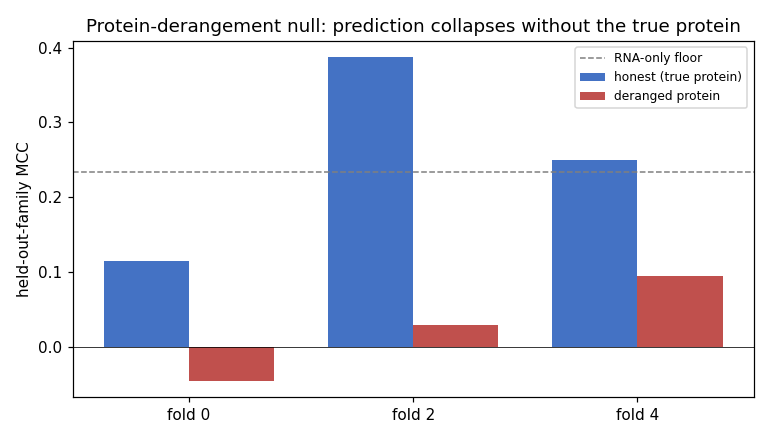

In [2]:
import matplotlib; matplotlib.use('Agg'); import matplotlib.pyplot as plt, numpy as np
ks=sorted(d,key=int); hs=[d[k]['honest'] for k in ks]; ds=[d[k]['deranged_mean'] for k in ks]
x=np.arange(len(ks)); w=0.38; fig,ax=plt.subplots(figsize=(7,4))
ax.bar(x-w/2,hs,w,label='honest (true protein)',color='#4472c4'); ax.bar(x+w/2,ds,w,label='deranged protein',color='#c0504d')
ax.axhline(0.234,ls='--',c='gray',lw=1,label='RNA-only floor'); ax.axhline(0,c='k',lw=0.5)
ax.set_xticks(x); ax.set_xticklabels([f'fold {k}' for k in ks]); ax.set_ylabel('held-out-family MCC')
ax.set_title('Protein-derangement null: prediction collapses without the true protein'); ax.legend(fontsize=8); fig.tight_layout()
fig.savefig('F2_derangement.png',dpi=110); plt.close(fig)
from IPython.display import Image; display(Image('F2_derangement.png'))

## Conclusion (corrects the earlier read)
Feeding the WRONG protein **collapses MCC from ~0.25 to ~0.03** (below the RNA floor). So the model **is conditioning on the protein** -- it is NOT pure RNA memorization, and the earlier 'protein ignored' framing was too strong. **But this refutes 'ignored', not 'no transfer'**: the derangement tests protein USE, and a model that memorized seen (protein,RNA) associations collapses here too. Read together with S1_depeek (protein-using model does NOT beat the protein-blind RNA-only baseline, 0.317 vs 0.234) and F1 (effect is flat vs family distance), the precise conclusion is: **the model uses protein IDENTITY as a consistency/lookup key on seen structure, not protein-FAMILY structure for generalization** -- used-but-non-generalizing. Caveat: folds 0/2/4 only (1/3 adapters lost to quota); tests use, not transfer.

*Provenance: deranged-protein inference on saved best_adapters, CUDA GPU; `mmpartnet_out/famfull3_derangement_null.json`.*